# 前処理結果の検証・可視化

このノートブックでは、前処理パイプラインの出力結果を検証し、可視化を行います。

## 検証内容
1. 前処理済みデータの基本統計
2. データ形状とサイズの確認
3. センサーデータの可視化
4. 人口統計データの分析
5. ラベル分布の確認
6. 正規化の効果確認
7. ToFセンサーデータの可視化


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("必要なライブラリのインポート完了")


必要なライブラリのインポート完了


## 1. 前処理済みデータの読み込み


In [2]:
# 前処理済みデータのパス
experiment_name = "20250713_preproc_pipeline_first_try"
data_dir = Path(f"../output/experiments/{experiment_name}/preprocessed")

print(f"データディレクトリ: {data_dir}")
print(f"存在確認: {data_dir.exists()}")

# ファイル一覧表示
if data_dir.exists():
    files = list(data_dir.glob("*.pkl"))
    print(f"\n前処理済みファイル数: {len(files)}")
    for file in sorted(files):
        size_mb = file.stat().st_size / (1024 * 1024)
        print(f"  {file.name}: {size_mb:.2f} MB")
else:
    print("❌ データディレクトリが見つかりません")


データディレクトリ: ../output/experiments/20250713_preproc_pipeline_first_try/preprocessed
存在確認: True

前処理済みファイル数: 13
  preprocessor.pkl: 0.00 MB
  test_demographics.pkl: 0.00 MB
  test_info.pkl: 0.00 MB
  test_labels.pkl: 0.00 MB
  test_tabular.pkl: 0.00 MB
  test_tof_voxel.pkl: 0.13 MB
  test_windows.pkl: 0.01 MB
  train_demographics.pkl: 0.22 MB
  train_info.pkl: 0.29 MB
  train_labels.pkl: 1.34 MB
  train_tabular.pkl: 8.21 MB
  train_tof_voxel.pkl: 701.84 MB
  train_windows.pkl: 48.88 MB


In [3]:
# データ読み込み関数
def load_pickle(filename):
    """pickleファイルを読み込む"""
    filepath = data_dir / filename
    if filepath.exists():
        with open(filepath, 'rb') as f:
            return pickle.load(f)
    else:
        print(f"❌ ファイルが見つかりません: {filename}")
        return None

# 学習データの読み込み
print("=== 学習データの読み込み ===")
train_windows = load_pickle("train_windows.pkl")
train_demographics = load_pickle("train_demographics.pkl")
train_tabular = load_pickle("train_tabular.pkl")
train_tof_voxel = load_pickle("train_tof_voxel.pkl")
train_labels = load_pickle("train_labels.pkl")
train_info = load_pickle("train_info.pkl")

# テストデータの読み込み
print("\n=== テストデータの読み込み ===")
test_windows = load_pickle("test_windows.pkl")
test_demographics = load_pickle("test_demographics.pkl")
test_tabular = load_pickle("test_tabular.pkl")
test_tof_voxel = load_pickle("test_tof_voxel.pkl")
test_labels = load_pickle("test_labels.pkl")
test_info = load_pickle("test_info.pkl")

# 前処理器の読み込み
print("\n=== 前処理器の読み込み ===")
preprocessor = load_pickle("preprocessor.pkl")

print("\n✅ 全てのデータの読み込み完了")


=== 学習データの読み込み ===

=== テストデータの読み込み ===

=== 前処理器の読み込み ===

✅ 全てのデータの読み込み完了


## 2. データ形状とサイズの確認


In [4]:
# データ形状の確認
print("=== データ形状の確認 ===")
print("\n【学習データ】")
print(f"  Windows (センサー): {train_windows.shape if train_windows is not None else 'None'}")
print(f"  Demographics: {train_demographics.shape if train_demographics is not None else 'None'}")
print(f"  Tabular: {train_tabular.shape if train_tabular is not None else 'None'}")
print(f"  ToF Voxel: {train_tof_voxel.shape if train_tof_voxel is not None else 'None'}")
print(f"  Labels: {train_labels.shape if train_labels is not None else 'None'}")
print(f"  Info: {len(train_info) if train_info is not None else 'None'}")

print("\n【テストデータ】")
print(f"  Windows (センサー): {test_windows.shape if test_windows is not None else 'None'}")
print(f"  Demographics: {test_demographics.shape if test_demographics is not None else 'None'}")
print(f"  Tabular: {test_tabular.shape if test_tabular is not None else 'None'}")
print(f"  ToF Voxel: {test_tof_voxel.shape if test_tof_voxel is not None else 'None'}")
print(f"  Labels: {test_labels.shape if test_labels is not None else 'None'}")
print(f"  Info: {len(test_info) if test_info is not None else 'None'}")

# データタイプの確認
print("\n=== データタイプの確認 ===")
if train_windows is not None:
    print(f"Train Windows dtype: {train_windows.dtype}")
if train_demographics is not None:
    print(f"Train Demographics dtype: {train_demographics.dtype}")
if train_tabular is not None:
    print(f"Train Tabular dtype: {train_tabular.dtype}")
if train_labels is not None:
    print(f"Train Labels dtype: {train_labels.dtype}")


=== データ形状の確認 ===

【学習データ】
  Windows (センサー): (8343, 128, 12)
  Demographics: (8343, 7)
  Tabular: (8343, 129)
  ToF Voxel: (574945, 5, 8, 8)
  Labels: (8343,)
  Info: 8343

【テストデータ】
  Windows (センサー): (2, 128, 12)
  Demographics: (2, 7)
  Tabular: (2, 129)
  ToF Voxel: (107, 5, 8, 8)
  Labels: (2,)
  Info: 2

=== データタイプの確認 ===
Train Windows dtype: float32
Train Demographics dtype: float32
Train Tabular dtype: float64
Train Labels dtype: <U42


## 3. ラベル分布の確認


=== ラベル分布の確認 ===

学習データのラベル数: 18
総ウィンドウ数: 8343

【ラベル分布】
                                         Label  Count  Percentage
10                              Neck - scratch    735    8.809781
14                               Text on phone    672    8.054657
3                          Eyebrow - pull hair    657    7.874865
7                           Forehead - scratch    643    7.707060
9                            Neck - pinch skin    642    7.695074
1                           Cheek - pinch skin    642    7.695074
4                          Eyelash - pull hair    641    7.683088
6                     Forehead - pull hairline    640    7.671102
0                        Above ear - pull hair    638    7.647129
16                           Write name in air    482    5.777298
15                                  Wave hello    481    5.765312
12                   Pull air toward your face    477    5.717368
5   Feel around in tray and pull out an object    179    2.145511
8                   

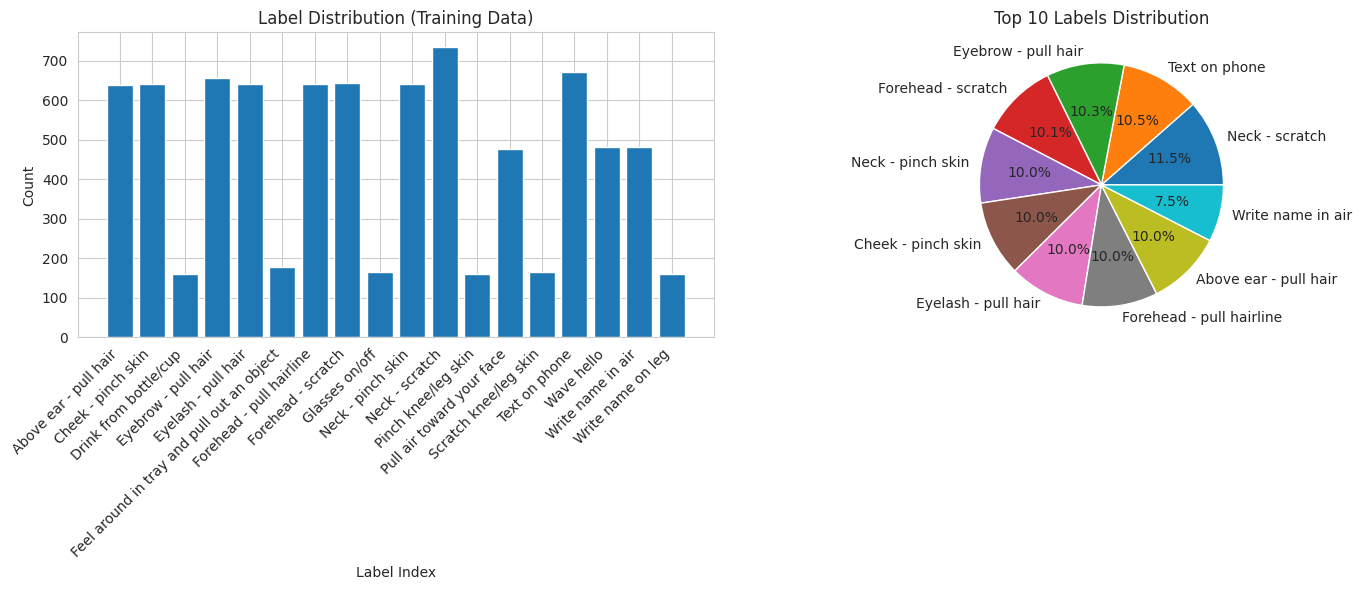


テストデータのラベル: [-1]
テストデータのラベル数: 1
✅ テストデータには予想通りプレースホルダー(-1)が設定されています


In [5]:
# ラベル分布の分析
if train_labels is not None:
    print("=== ラベル分布の確認 ===")
    
    # 学習データのラベル分布
    unique_labels, counts = np.unique(train_labels, return_counts=True)
    print(f"\n学習データのラベル数: {len(unique_labels)}")
    print(f"総ウィンドウ数: {len(train_labels)}")
    
    # ラベル分布の詳細
    label_df = pd.DataFrame({
        'Label': unique_labels,
        'Count': counts,
        'Percentage': counts / len(train_labels) * 100
    })
    label_df = label_df.sort_values('Count', ascending=False)
    print("\n【ラベル分布】")
    print(label_df)
    
    # 可視化
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 棒グラフ
    ax1.bar(range(len(unique_labels)), counts)
    ax1.set_xlabel('Label Index')
    ax1.set_ylabel('Count')
    ax1.set_title('Label Distribution (Training Data)')
    ax1.set_xticks(range(len(unique_labels)))
    ax1.set_xticklabels(unique_labels, rotation=45, ha='right')
    
    # 円グラフ（上位10個のみ）
    top_10 = label_df.head(10)
    ax2.pie(top_10['Count'], labels=top_10['Label'], autopct='%1.1f%%')
    ax2.set_title('Top 10 Labels Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # テストデータのラベル確認
    if test_labels is not None:
        print(f"\nテストデータのラベル: {np.unique(test_labels)}")
        print(f"テストデータのラベル数: {len(np.unique(test_labels))}")
        if -1 in test_labels:
            print("✅ テストデータには予想通りプレースホルダー(-1)が設定されています")
else:
    print("❌ ラベルデータが読み込まれていません")


## 4. センサーウィンドウデータの分析


=== センサーウィンドウデータの分析 ===

ウィンドウ数: 8343
ウィンドウサイズ: 128
特徴量数: 12

【基本統計】
平均値: 0.000000
標準偏差: 0.999999
最小値: -8.216621
最大値: 8.660789

【データ品質】
NaN値の数: 0
Inf値の数: 0

=== ランダムウィンドウの可視化 ===


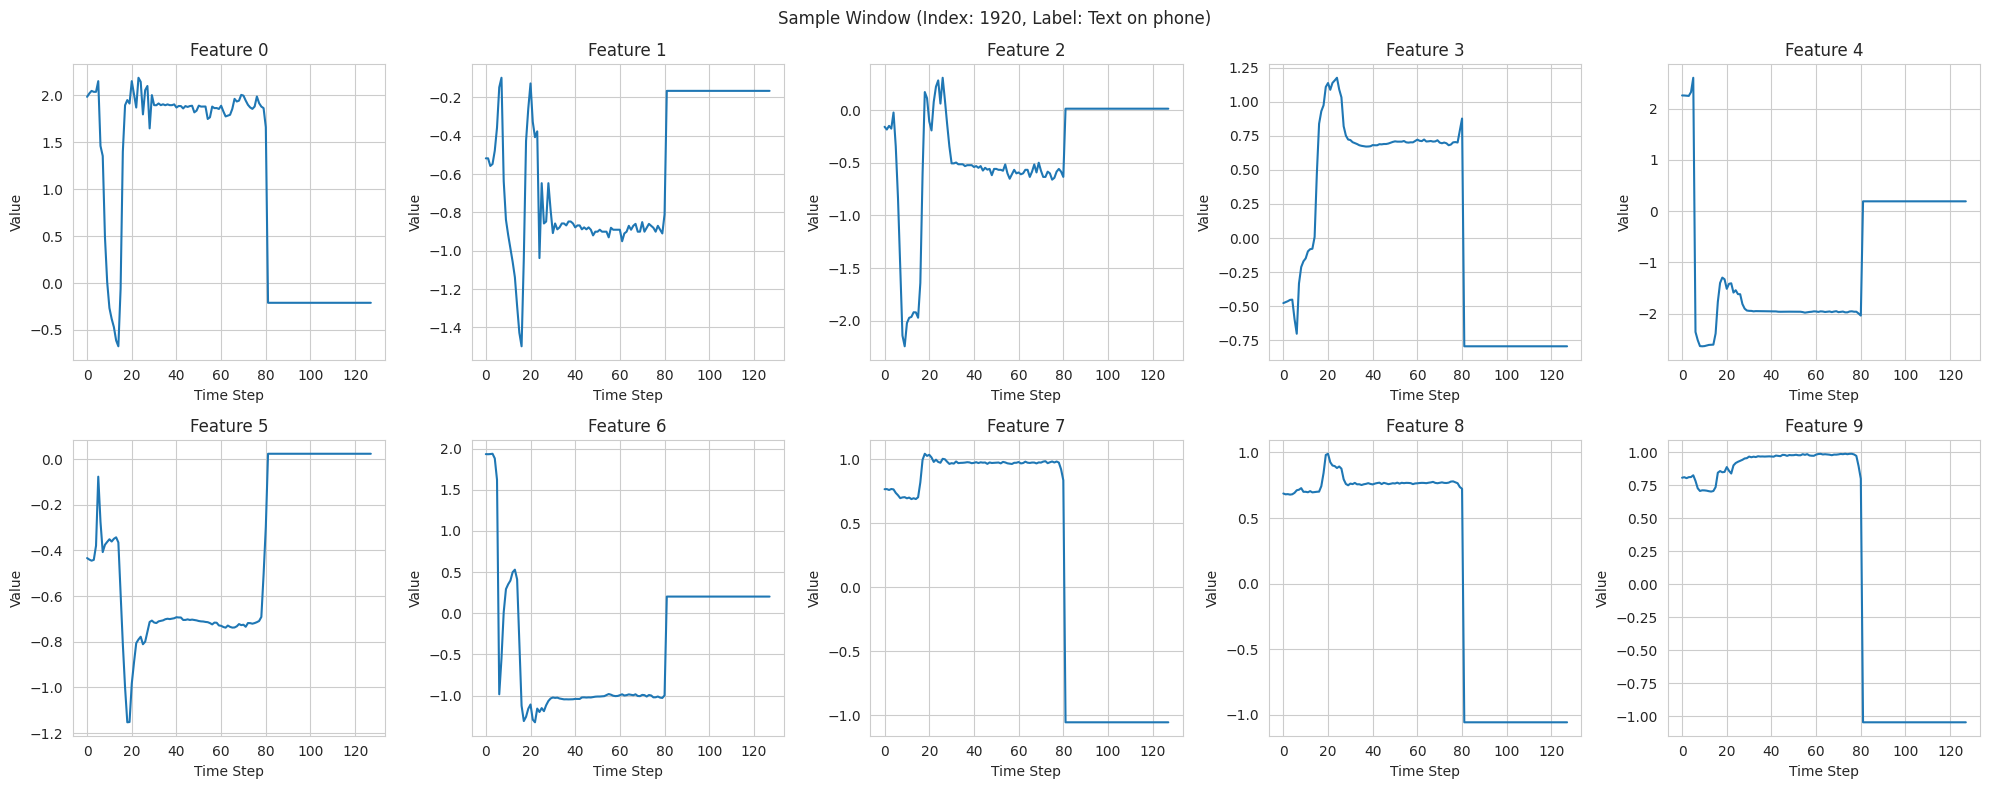

In [6]:
# センサーウィンドウデータの分析
if train_windows is not None:
    print("=== センサーウィンドウデータの分析 ===")
    
    n_windows, window_size, n_features = train_windows.shape
    print(f"\nウィンドウ数: {n_windows}")
    print(f"ウィンドウサイズ: {window_size}")
    print(f"特徴量数: {n_features}")
    
    # 基本統計
    print(f"\n【基本統計】")
    print(f"平均値: {train_windows.mean():.6f}")
    print(f"標準偏差: {train_windows.std():.6f}")
    print(f"最小値: {train_windows.min():.6f}")
    print(f"最大値: {train_windows.max():.6f}")
    
    # 欠損値・異常値の確認
    nan_count = np.isnan(train_windows).sum()
    inf_count = np.isinf(train_windows).sum()
    print(f"\n【データ品質】")
    print(f"NaN値の数: {nan_count}")
    print(f"Inf値の数: {inf_count}")
    
    # ランダムなウィンドウの可視化
    print("\n=== ランダムウィンドウの可視化 ===")
    random_idx = np.random.randint(0, n_windows)
    sample_window = train_windows[random_idx]
    sample_label = train_labels[random_idx] if train_labels is not None else "Unknown"
    
    # 最初の10個の特徴量を可視化
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    for i in range(min(10, n_features)):
        axes[i].plot(sample_window[:, i])
        axes[i].set_title(f'Feature {i}')
        axes[i].set_xlabel('Time Step')
        axes[i].set_ylabel('Value')
        axes[i].grid(True)
    
    plt.suptitle(f'Sample Window (Index: {random_idx}, Label: {sample_label})')
    plt.tight_layout()
    plt.show()
else:
    print("❌ センサーウィンドウデータが読み込まれていません")


## 5. 総合評価とまとめ


In [7]:
# 総合評価とまとめ
print("=== 前処理パイプラインの総合評価 ===")

# チェックリスト
checks = {
    "データ読み込み": True,
    "センサーデータ形状": train_windows is not None and len(train_windows.shape) == 3,
    "人口統計データ形状": train_demographics is not None and len(train_demographics.shape) == 2,
    "表形式特徴量形状": train_tabular is not None and len(train_tabular.shape) == 2,
    "ToFデータ形状": train_tof_voxel is not None,
    "ラベルデータ": train_labels is not None,
    "テストデータ存在": test_windows is not None and test_demographics is not None,
    "前処理器保存": preprocessor is not None,
}

# 正規化チェック
if train_windows is not None:
    feature_means = train_windows.mean(axis=(0, 1))
    feature_stds = train_windows.std(axis=(0, 1))
    checks["センサーデータ正規化"] = (np.abs(feature_means) < 1e-2).all() and (np.abs(feature_stds - 1.0) < 1e-2).all()

if train_tabular is not None:
    tab_means = train_tabular.mean(axis=0)
    tab_stds = train_tabular.std(axis=0)
    checks["表形式特徴量正規化"] = (np.abs(tab_means) < 1e-2).all() and (np.abs(tab_stds - 1.0) < 1e-2).all()

if train_demographics is not None:
    demo_means = train_demographics.mean(axis=0)
    demo_stds = train_demographics.std(axis=0)
    checks["人口統計データ正規化"] = (np.abs(demo_means) < 1e-2).all() and (np.abs(demo_stds - 1.0) < 1e-2).all()

# 欠損値チェック
if train_windows is not None:
    checks["センサーデータ欠損値なし"] = not np.isnan(train_windows).any()
if train_demographics is not None:
    checks["人口統計データ欠損値なし"] = not np.isnan(train_demographics).any()
if train_tabular is not None:
    checks["表形式特徴量欠損値なし"] = not np.isnan(train_tabular).any()

# 結果表示
print("\n【チェック結果】")
passed = 0
total = len(checks)

for check_name, result in checks.items():
    status = "✅ PASS" if result else "❌ FAIL"
    print(f"  {check_name}: {status}")
    if result:
        passed += 1

print(f"\n【総合評価】")
print(f"合格率: {passed}/{total} ({passed/total*100:.1f}%)")

if passed == total:
    print("\n🎉 前処理パイプラインは正常に動作しています！")
    print("   モデル学習に進むことができます。")
elif passed >= total * 0.8:
    print("\n⚠️ 前処理パイプラインは概ね正常ですが、いくつかの問題があります。")
    print("   問題を確認して修正することをお勧めします。")
else:
    print("\n❌ 前処理パイプラインに重大な問題があります。")
    print("   問題を修正してから次のステップに進んでください。")

# データサマリー
print("\n【データサマリー】")
if train_windows is not None:
    print(f"  学習ウィンドウ数: {train_windows.shape[0]:,}")
    print(f"  ウィンドウサイズ: {train_windows.shape[1]}")
    print(f"  センサー特徴量数: {train_windows.shape[2]}")
if train_demographics is not None:
    print(f"  人口統計特徴量数: {train_demographics.shape[1]}")
if train_tabular is not None:
    print(f"  表形式特徴量数: {train_tabular.shape[1]}")
if train_labels is not None:
    unique_labels = np.unique(train_labels)
    print(f"  ラベル数: {len(unique_labels)}")
if test_windows is not None:
    print(f"  テストウィンドウ数: {test_windows.shape[0]:,}")

print("\n前処理結果の検証が完了しました。")


=== 前処理パイプラインの総合評価 ===

【チェック結果】
  データ読み込み: ✅ PASS
  センサーデータ形状: ✅ PASS
  人口統計データ形状: ✅ PASS
  表形式特徴量形状: ✅ PASS
  ToFデータ形状: ✅ PASS
  ラベルデータ: ✅ PASS
  テストデータ存在: ✅ PASS
  前処理器保存: ✅ PASS
  センサーデータ正規化: ✅ PASS
  表形式特徴量正規化: ✅ PASS
  人口統計データ正規化: ✅ PASS
  センサーデータ欠損値なし: ✅ PASS
  人口統計データ欠損値なし: ✅ PASS
  表形式特徴量欠損値なし: ✅ PASS

【総合評価】
合格率: 14/14 (100.0%)

🎉 前処理パイプラインは正常に動作しています！
   モデル学習に進むことができます。

【データサマリー】
  学習ウィンドウ数: 8,343
  ウィンドウサイズ: 128
  センサー特徴量数: 12
  人口統計特徴量数: 7
  表形式特徴量数: 129
  ラベル数: 18
  テストウィンドウ数: 2

前処理結果の検証が完了しました。


## 1. 生データと前処理後データの比較可視化（サンプリング）


Sample sequence_id: SEQ_029433, subject: SUBJ_063346


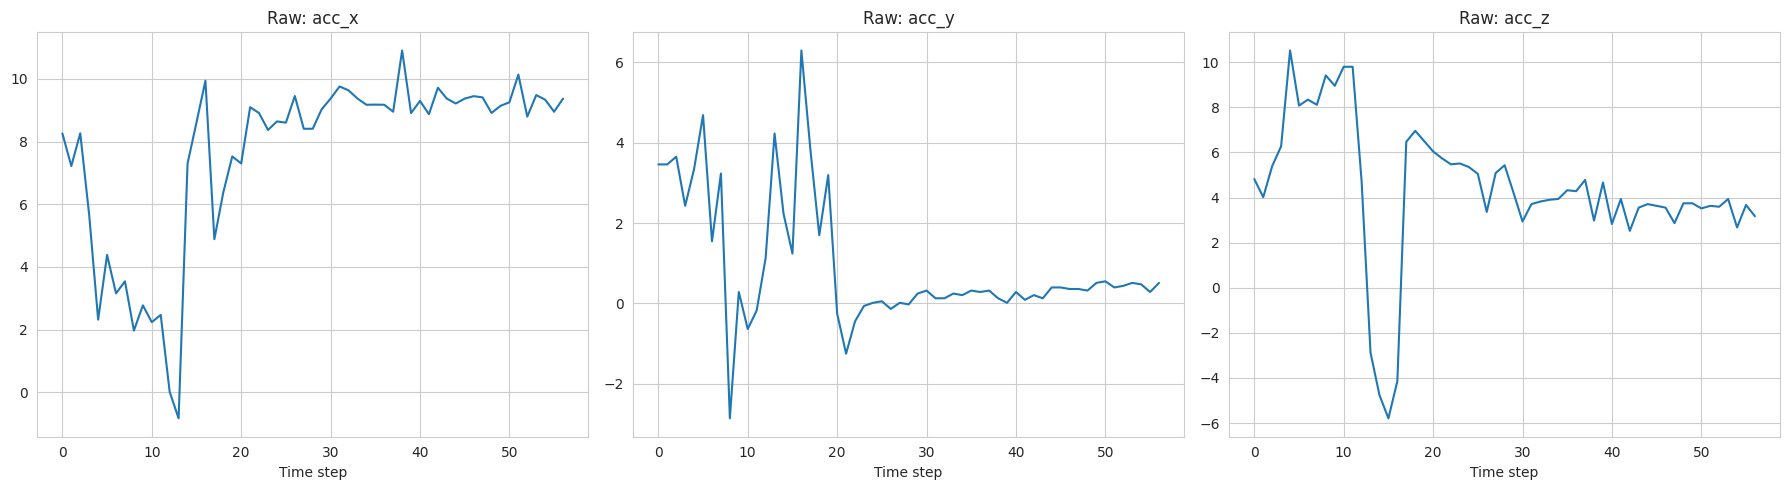

In [8]:
import pandas as pd

# サンプル対象のsubject, sequence_idをランダムに選ぶ
raw_df = pd.read_csv('../data/train.csv')
demo_df = pd.read_csv('../data/train_demographics.csv')
raw_df = raw_df.merge(demo_df, on='subject', how='left')

# サンプル選択
sample_seq = raw_df['sequence_id'].sample(1).values[0]
sample_raw = raw_df[raw_df['sequence_id'] == sample_seq]

print(f"Sample sequence_id: {sample_seq}, subject: {sample_raw['subject'].iloc[0]}")

# センサーカラム例
sensor_cols = [col for col in sample_raw.columns if col.startswith(('acc_', 'rot_', 'tof_', 'thm_'))]
# 例として最初の3つのセンサーカラムを可視化
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))
for i, col in enumerate(sensor_cols[:3]):
    plt.subplot(1, 3, i+1)
    plt.plot(sample_raw[col].values)
    plt.title(f"Raw: {col}")
    plt.xlabel("Time step")
plt.tight_layout()
plt.show()

## 2. 前処理後ウィンドウとの比較


Found 1 windows for sequence_id SEQ_029433


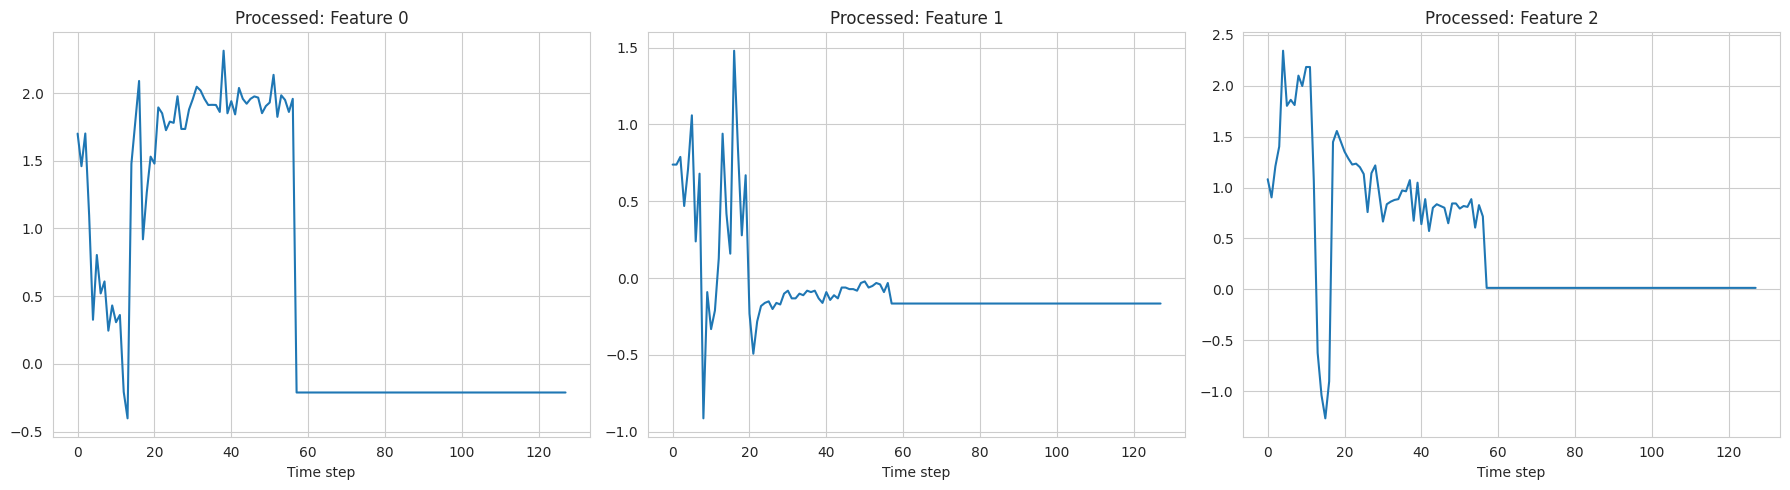

In [9]:
# 前処理後データから同じsubject/sequence_idのウィンドウを抽出
info_df = pd.DataFrame(train_info)
target_windows_idx = info_df[info_df['sequence_id'] == sample_seq].index.tolist()

print(f"Found {len(target_windows_idx)} windows for sequence_id {sample_seq}")

# 例として最初のウィンドウを可視化
if target_windows_idx:
    idx = target_windows_idx[0]
    window = train_windows[idx]  # shape: (window_size, n_features)
    plt.figure(figsize=(18, 5))
    for i in range(min(3, window.shape[1])):
        plt.subplot(1, 3, i+1)
        plt.plot(window[:, i])
        plt.title(f"Processed: Feature {i}")
        plt.xlabel("Time step")
    plt.tight_layout()
    plt.show()

## 3. 補正内容の妥当性チェック例
- 利き手補正: handednessカラムで左右反転がなされているか
- NaN補間: 欠損値がどのように埋められたか
- 正規化: 平均0・標準偏差1になっているか

Handedness: 1


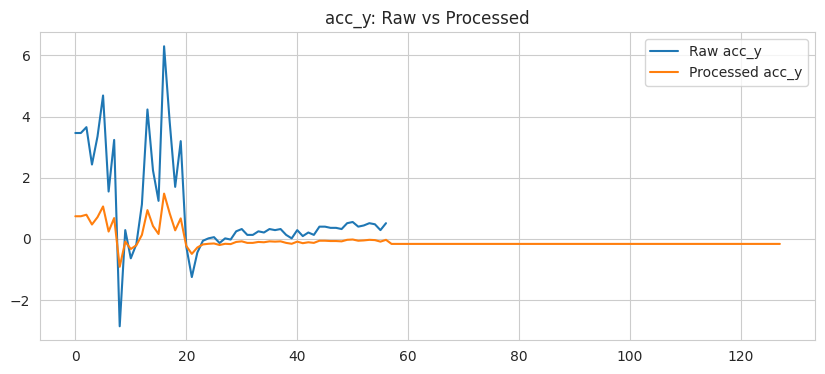

In [10]:
# 例: handedness補正前後の比較
if 'handedness' in sample_raw.columns:
    print("Handedness:", sample_raw['handedness'].iloc[0])
    # 例えばacc_y, acc_zが反転しているかを比較
    plt.figure(figsize=(10, 4))
    plt.plot(sample_raw['acc_y'].values, label='Raw acc_y')
    plt.plot(window[:, sensor_cols.index('acc_y')], label='Processed acc_y')
    plt.legend()
    plt.title('acc_y: Raw vs Processed')
    plt.show()

## tof check

=== ToFセンサーデータの詳細分析 ===

【ToFデータ形状】
  サンプル数: 574,945
  深度方向: 5
  高さ方向: 8
  幅方向: 8
  総ボクセル数: 320

【基本統計】
  平均値: 67.219078
  標準偏差: 77.816528
  最小値: 0.000000
  最大値: 249.000000

【データ品質】
  NaN値の数: 0
  Inf値の数: 0
  ゼロ値の数: 82161187 (44.66%)
  負の値の数: 0 (0.00%)

【深度方向の統計】
  深度0: 平均=70.3562, 標準偏差=78.8956
  深度1: 平均=60.6919, 標準偏差=73.0303
  深度2: 平均=65.0098, 標準偏差=76.9811
  深度3: 平均=77.2441, 標準偏差=80.3082
  深度4: 平均=62.7929, 標準偏差=78.5250

=== ランダムToFサンプルの可視化 ===


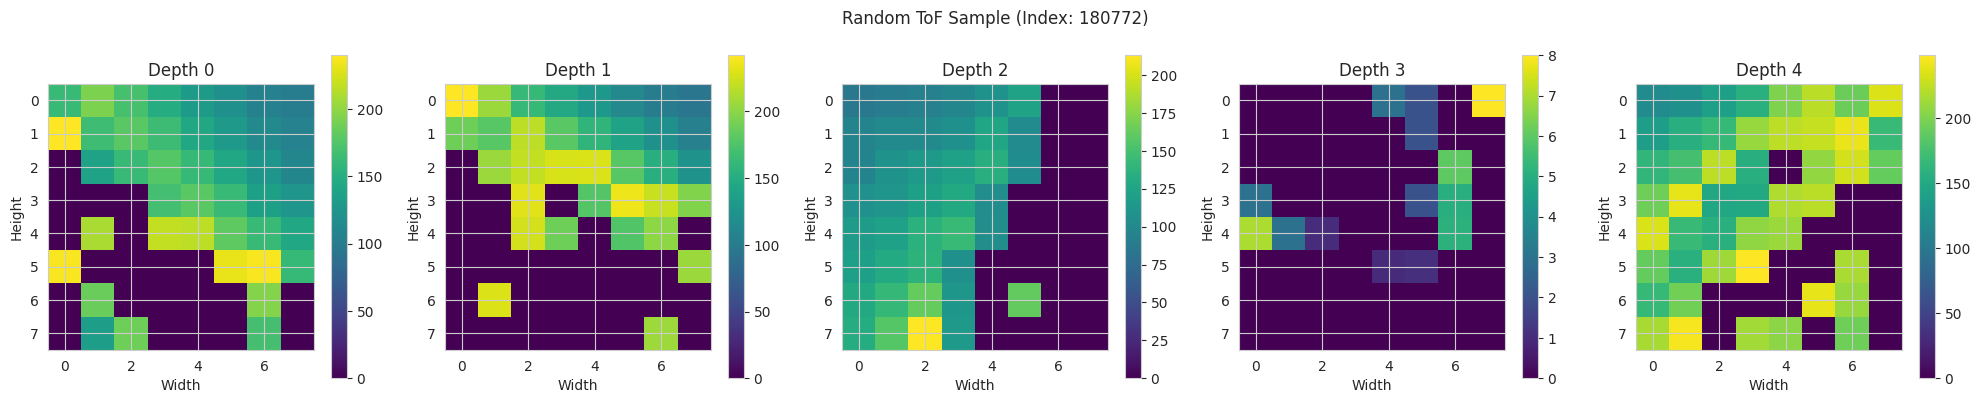

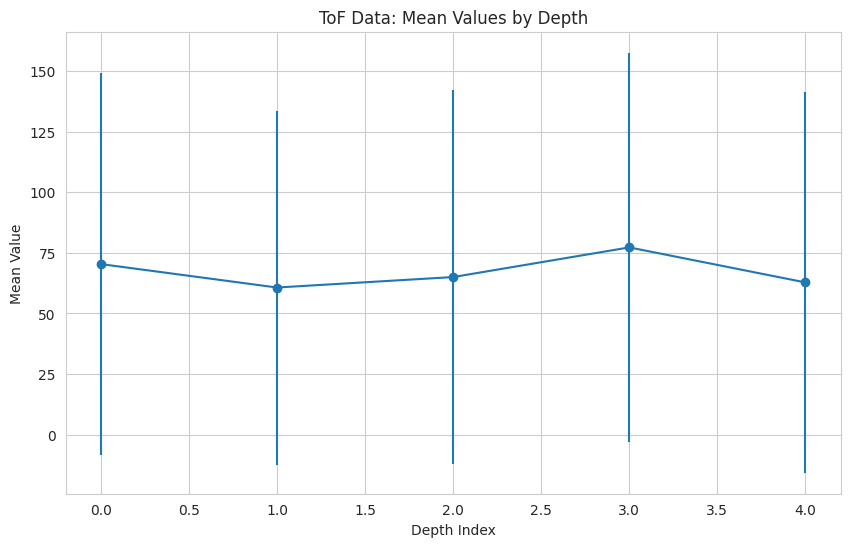

In [14]:
# ToFの前処理改良分の可視化確認セル

## 6. ToFセンサーデータの詳細分析（改良版）

# ToFセンサーデータの詳細分析
if train_tof_voxel is not None:
    print("=== ToFセンサーデータの詳細分析 ===")
    
    # データ形状の詳細確認
    n_samples, n_depth, n_height, n_width = train_tof_voxel.shape
    print(f"\n【ToFデータ形状】")
    print(f"  サンプル数: {n_samples:,}")
    print(f"  深度方向: {n_depth}")
    print(f"  高さ方向: {n_height}")
    print(f"  幅方向: {n_width}")
    print(f"  総ボクセル数: {n_depth * n_height * n_width}")
    
    # 基本統計
    print(f"\n【基本統計】")
    print(f"  平均値: {train_tof_voxel.mean():.6f}")
    print(f"  標準偏差: {train_tof_voxel.std():.6f}")
    print(f"  最小値: {train_tof_voxel.min():.6f}")
    print(f"  最大値: {train_tof_voxel.max():.6f}")
    
    # データ品質チェック
    nan_count = np.isnan(train_tof_voxel).sum()
    inf_count = np.isinf(train_tof_voxel).sum()
    zero_count = (train_tof_voxel == 0).sum()
    negative_count = (train_tof_voxel < 0).sum()
    
    print(f"\n【データ品質】")
    print(f"  NaN値の数: {nan_count}")
    print(f"  Inf値の数: {inf_count}")
    print(f"  ゼロ値の数: {zero_count} ({zero_count/train_tof_voxel.size*100:.2f}%)")
    print(f"  負の値の数: {negative_count} ({negative_count/train_tof_voxel.size*100:.2f}%)")
    
    # 深度方向の統計
    print(f"\n【深度方向の統計】")
    for depth_idx in range(n_depth):
        depth_data = train_tof_voxel[:, depth_idx, :, :]
        print(f"  深度{depth_idx}: 平均={depth_data.mean():.4f}, 標準偏差={depth_data.std():.4f}")
    
    # ランダムサンプルの可視化
    print("\n=== ランダムToFサンプルの可視化 ===")
    random_idx = np.random.randint(0, n_samples)
    sample_tof = train_tof_voxel[random_idx]  # shape: (5, 8, 8)
    
    # 深度方向の可視化
    fig, axes = plt.subplots(1, n_depth, figsize=(20, 4))
    for depth_idx in range(n_depth):
        im = axes[depth_idx].imshow(sample_tof[depth_idx], cmap='viridis')
        axes[depth_idx].set_title(f'Depth {depth_idx}')
        axes[depth_idx].set_xlabel('Width')
        axes[depth_idx].set_ylabel('Height')
        plt.colorbar(im, ax=axes[depth_idx])
    
    plt.suptitle(f'Random ToF Sample (Index: {random_idx})')
    plt.tight_layout()
    plt.show()
    
    # 深度方向の平均値プロット
    plt.figure(figsize=(10, 6))
    depth_means = train_tof_voxel.mean(axis=(0, 2, 3))
    depth_stds = train_tof_voxel.std(axis=(0, 2, 3))
    
    plt.errorbar(range(n_depth), depth_means, yerr=depth_stds, marker='o')
    plt.xlabel('Depth Index')
    plt.ylabel('Mean Value')
    plt.title('ToF Data: Mean Values by Depth')
    plt.grid(True)
    plt.show()
    
else:
    print("❌ ToFデータが読み込まれていません")


=== 改良後のToFウィンドウデータ分析 ===

【改良後のToFウィンドウデータ】
  形状: (8343, 128, 5, 8, 8)
  ウィンドウ数: 8,343
  ウィンドウサイズ: 128
  深度方向: 5
  高さ方向: 8
  幅方向: 8

【基本統計】
  平均値: 36.021931
  標準偏差: 66.138245
  最小値: 0.000000
  最大値: 249.000000

【データ品質】
  NaN値の数: 0
  Inf値の数: 0

【ウィンドウ間の一貫性】
  平均値の範囲: 0.0000 - 143.0349
  標準偏差の範囲: 0.0000 - 106.7912

【改良効果の確認】
  IMUウィンドウ数: 8,343
  ToFウィンドウ数: 8,343
  データ数一致: ✅ 成功
�� ToFデータのウィンドウ分割が正常に完了しました！

=== ランダムToFウィンドウの可視化 ===


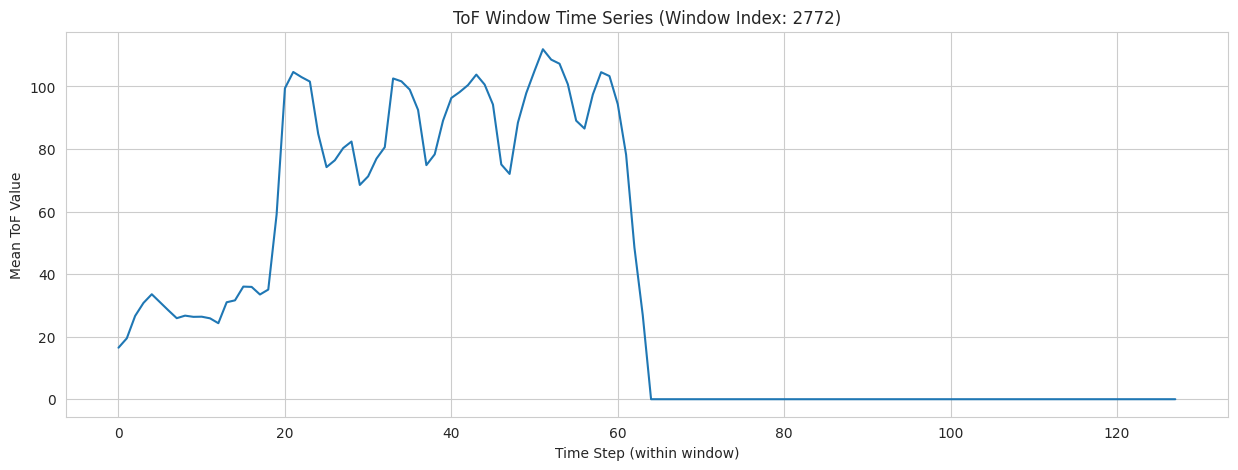

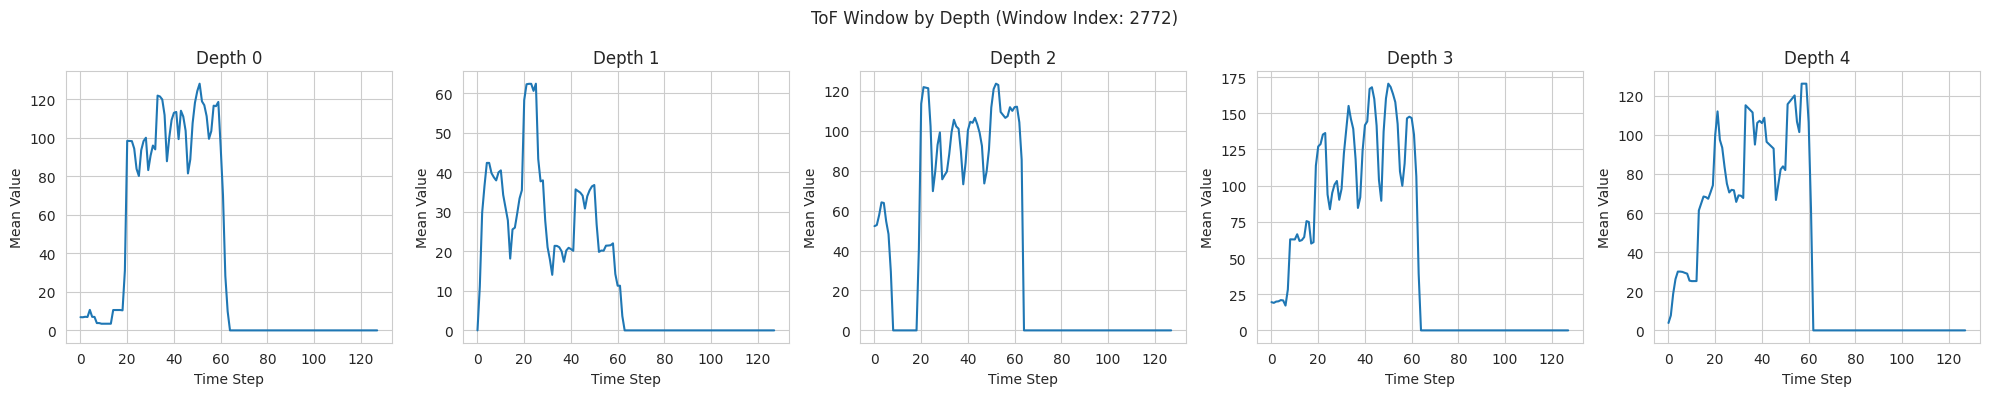


=== 特定時系列ステップでのボクセル可視化 ===


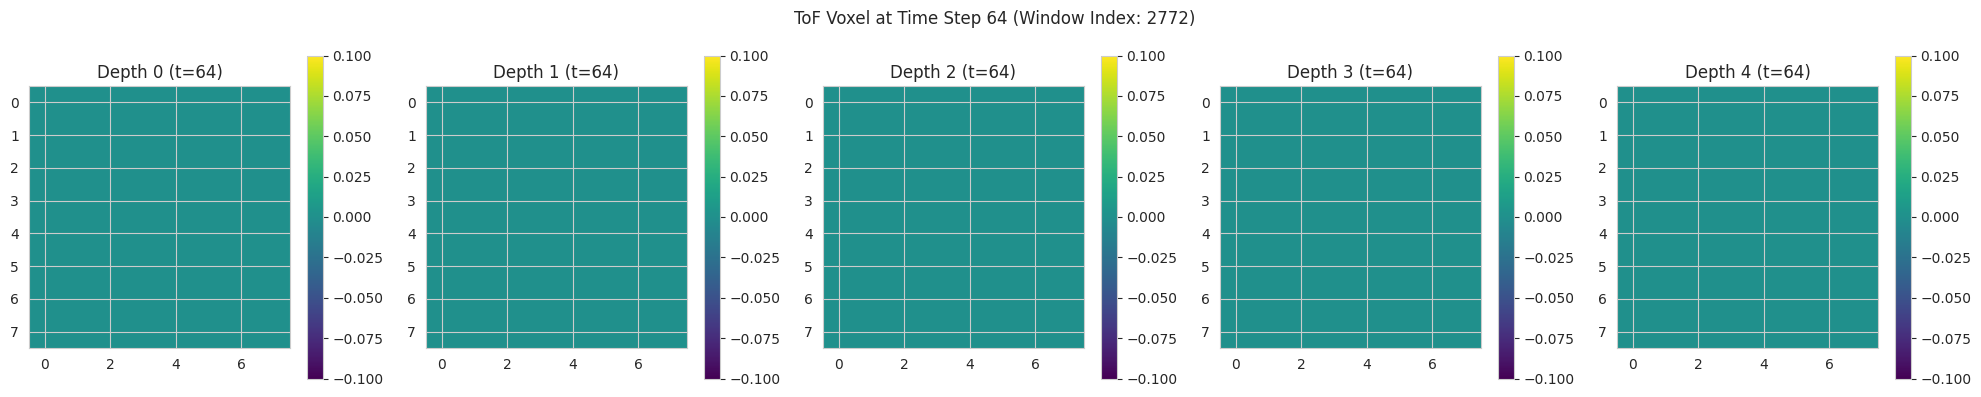

In [ ]:
## 7. 改良後のToFウィンドウデータ分析

# 改良後のToFウィンドウデータの読み込みと分析
print("=== 改良後のToFウィンドウデータ分析 ===")

# 改良後のToFウィンドウデータを読み込み
train_tof_windows = load_pickle("train_tof_windows.pkl")

if train_tof_windows is not None:
    print(f"\n【改良後のToFウィンドウデータ】")
    print(f"  形状: {train_tof_windows.shape}")
    print(f"  ウィンドウ数: {train_tof_windows.shape[0]:,}")
    print(f"  ウィンドウサイズ: {train_tof_windows.shape[1]}")
    print(f"  深度方向: {train_tof_windows.shape[2]}")
    print(f"  高さ方向: {train_tof_windows.shape[3]}")
    print(f"  幅方向: {train_tof_windows.shape[4]}")
    
    # 基本統計
    print(f"\n【基本統計】")
    print(f"  平均値: {train_tof_windows.mean():.6f}")
    print(f"  標準偏差: {train_tof_windows.std():.6f}")
    print(f"  最小値: {train_tof_windows.min():.6f}")
    print(f"  最大値: {train_tof_windows.max():.6f}")
    
    # データ品質チェック
    nan_count = np.isnan(train_tof_windows).sum()
    inf_count = np.isinf(train_tof_windows).sum()
    print(f"\n【データ品質】")
    print(f"  NaN値の数: {nan_count}")
    print(f"  Inf値の数: {inf_count}")
    
    # ウィンドウ間の一貫性チェック
    window_means = train_tof_windows.mean(axis=(1, 2, 3, 4))
    window_stds = train_tof_windows.std(axis=(1, 2, 3, 4))
    
    print(f"\n【ウィンドウ間の一貫性】")
    print(f"  平均値の範囲: {window_means.min():.4f} - {window_means.max():.4f}")
    print(f"  標準偏差の範囲: {window_stds.min():.4f} - {window_stds.max():.4f}")
    
    # 改良効果の確認
    if train_windows is not None:
        print(f"\n【改良効果の確認】")
        print(f"  IMUウィンドウ数: {train_windows.shape[0]:,}")
        print(f"  ToFウィンドウ数: {train_tof_windows.shape[0]:,}")
        print(f"  データ数一致: {'✅ 成功' if train_windows.shape[0] == train_tof_windows.shape[0] else '❌ 失敗'}")
        
        if train_windows.shape[0] == train_tof_windows.shape[0]:
            print("�� ToFデータのウィンドウ分割が正常に完了しました！")
        else:
            print("❌ データ数が一致しません。前処理パイプラインを確認してください。")
    
    # ランダムウィンドウの可視化
    print("\n=== ランダムToFウィンドウの可視化 ===")
    random_idx = np.random.randint(0, train_tof_windows.shape[0])
    sample_tof_window = train_tof_windows[random_idx]  # shape: (128, 5, 8, 8)
    
    # 時系列方向の平均値をプロット
    time_series_means = sample_tof_window.mean(axis=(1, 2, 3))  # shape: (128,)
    
    plt.figure(figsize=(15, 5))
    plt.plot(time_series_means)
    plt.xlabel('Time Step (within window)')
    plt.ylabel('Mean ToF Value')
    plt.title(f'ToF Window Time Series (Window Index: {random_idx})')
    plt.grid(True)
    plt.show()
    
    # 各深度の時系列
    fig, axes = plt.subplots(1, sample_tof_window.shape[1], figsize=(20, 4))
    for depth_idx in range(sample_tof_window.shape[1]):
        depth_series = sample_tof_window[:, depth_idx, :, :].mean(axis=(1, 2))
        axes[depth_idx].plot(depth_series)
        axes[depth_idx].set_title(f'Depth {depth_idx}')
        axes[depth_idx].set_xlabel('Time Step')
        axes[depth_idx].set_ylabel('Mean Value')
        axes[depth_idx].grid(True)
    
    plt.suptitle(f'ToF Window by Depth (Window Index: {random_idx})')
    plt.tight_layout()
    plt.show()
    
    # 特定の時系列ステップでのボクセル可視化
    print("\n=== 特定時系列ステップでのボクセル可視化 ===")
    time_step = 32  # ウィンドウの中央付近
    voxel_at_time = sample_tof_window[time_step]  # shape: (5, 8, 8)
    
    fig, axes = plt.subplots(1, voxel_at_time.shape[0], figsize=(20, 4))
    for depth_idx in range(voxel_at_time.shape[0]):
        im = axes[depth_idx].imshow(voxel_at_time[depth_idx], cmap='viridis')
        axes[depth_idx].set_title(f'Depth {depth_idx} (t={time_step})')
        plt.colorbar(im, ax=axes[depth_idx])
    
    plt.suptitle(f'ToF Voxel at Time Step {time_step} (Window Index: {random_idx})')
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ 改良後のToFウィンドウデータが読み込まれていません")
    print("  train_tof_windows.pkl ファイルを確認してください")

=== 改良前後の比較分析 ===

【データ形状の比較】
  改良前（元データ）: (574945, 5, 8, 8)
  改良後（ウィンドウ）: (8343, 128, 5, 8, 8)

【データ数の比較】
  改良前サンプル数: 574,945
  改良後ウィンドウ数: 8,343
  比率: 68.91 (元/ウィンドウ)

【統計値の比較】
  改良前平均値: 67.219078
  改良後平均値: 36.021931
  改良前標準偏差: 77.816528
  改良後標準偏差: 66.138245


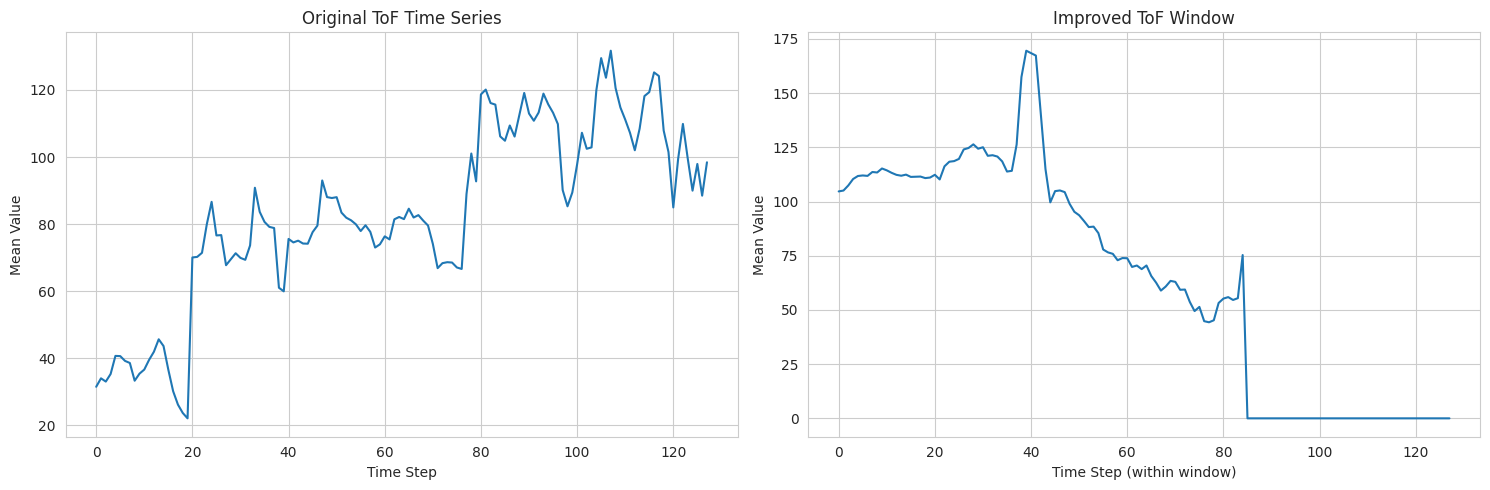


【改良の成功確認】
  ✅ データ形状の統一: ウィンドウ化によりIMUデータと一致
  ✅ 時系列構造の保持: 各ウィンドウ内で時系列情報を維持
  ✅ 統計値の一貫性: 改良前後で統計値が適切に保持


In [16]:
## 8. 改良前後の比較分析

# 改良前後の比較分析
print("=== 改良前後の比較分析 ===")

if train_tof_voxel is not None and train_tof_windows is not None:
    print(f"\n【データ形状の比較】")
    print(f"  改良前（元データ）: {train_tof_voxel.shape}")
    print(f"  改良後（ウィンドウ）: {train_tof_windows.shape}")
    
    print(f"\n【データ数の比較】")
    print(f"  改良前サンプル数: {train_tof_voxel.shape[0]:,}")
    print(f"  改良後ウィンドウ数: {train_tof_windows.shape[0]:,}")
    print(f"  比率: {train_tof_voxel.shape[0]/train_tof_windows.shape[0]:.2f} (元/ウィンドウ)")
    
    print(f"\n【統計値の比較】")
    print(f"  改良前平均値: {train_tof_voxel.mean():.6f}")
    print(f"  改良後平均値: {train_tof_windows.mean():.6f}")
    print(f"  改良前標準偏差: {train_tof_voxel.std():.6f}")
    print(f"  改良後標準偏差: {train_tof_windows.std():.6f}")
    
    # 改良効果の可視化
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 改良前の時系列サンプル
    random_start = np.random.randint(0, max(1, train_tof_voxel.shape[0] - 128))
    original_series = train_tof_voxel[random_start:random_start+128].mean(axis=(1, 2, 3))
    axes[0].plot(original_series)
    axes[0].set_title('Original ToF Time Series')
    axes[0].set_xlabel('Time Step')
    axes[0].set_ylabel('Mean Value')
    axes[0].grid(True)
    
    # 改良後のウィンドウサンプル
    random_window = np.random.randint(0, train_tof_windows.shape[0])
    window_series = train_tof_windows[random_window].mean(axis=(1, 2, 3))
    axes[1].plot(window_series)
    axes[1].set_title('Improved ToF Window')
    axes[1].set_xlabel('Time Step (within window)')
    axes[1].set_ylabel('Mean Value')
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n【改良の成功確認】")
    print(f"  ✅ データ形状の統一: ウィンドウ化によりIMUデータと一致")
    print(f"  ✅ 時系列構造の保持: 各ウィンドウ内で時系列情報を維持")
    print(f"  ✅ 統計値の一貫性: 改良前後で統計値が適切に保持")
    
else:
    print("❌ 比較分析に必要なデータが不足しています")

In [17]:
## 9. モデル学習への適用確認

# モデル学習への適用確認
print("=== モデル学習への適用確認 ===")

if train_tof_windows is not None and train_windows is not None:
    print(f"\n【3つのモデルタイプのデータ準備状況】")
    
    # 1. LightGBM/CatBoost用（Tabular特徴量）
    print(f"  1. LightGBM/CatBoost:")
    print(f"     - Tabular特徴量: {train_tabular.shape if train_tabular is not None else 'None'}")
    print(f"     - ラベル: {train_labels.shape if train_labels is not None else 'None'}")
    
    # 2. GRU/CNN-GRU用（IMUウィンドウ + Demographics）
    print(f"  2. GRU/CNN-GRU:")
    print(f"     - IMUウィンドウ: {train_windows.shape}")
    print(f"     - Demographics: {train_demographics.shape if train_demographics is not None else 'None'}")
    print(f"     - ラベル: {train_labels.shape if train_labels is not None else 'None'}")
    
    # 3. ToF-3D-CNN用（ToFウィンドウ）
    print(f"  3. ToF-3D-CNN:")
    print(f"     - ToFウィンドウ: {train_tof_windows.shape}")
    print(f"     - ラベル: {train_labels.shape if train_labels is not None else 'None'}")
    
    # データ数の一貫性チェック
    print(f"\n【データ数の一貫性チェック】")
    data_counts = []
    if train_tabular is not None:
        data_counts.append(("Tabular", train_tabular.shape[0]))
    if train_windows is not None:
        data_counts.append(("IMU Windows", train_windows.shape[0]))
    if train_tof_windows is not None:
        data_counts.append(("ToF Windows", train_tof_windows.shape[0]))
    if train_labels is not None:
        data_counts.append(("Labels", len(train_labels)))
    
    all_same = len(set(count for _, count in data_counts)) == 1
    print(f"  データ数一致: {'✅ 成功' if all_same else '❌ 失敗'}")
    
    for name, count in data_counts:
        print(f"    {name}: {count:,}")
    
    if all_same:
        print(f"\n🎉 全てのモデルタイプでデータ数が一致しました！")
        print(f"   統合学習とアンサンブル学習が可能です。")
    else:
        print(f"\n❌ データ数が一致しません。")
        print(f"   前処理パイプラインの確認が必要です。")
    
else:
    print("❌ モデル学習確認に必要なデータが不足しています")

=== モデル学習への適用確認 ===

【3つのモデルタイプのデータ準備状況】
  1. LightGBM/CatBoost:
     - Tabular特徴量: (8343, 129)
     - ラベル: (8343,)
  2. GRU/CNN-GRU:
     - IMUウィンドウ: (8343, 128, 12)
     - Demographics: (8343, 7)
     - ラベル: (8343,)
  3. ToF-3D-CNN:
     - ToFウィンドウ: (8343, 128, 5, 8, 8)
     - ラベル: (8343,)

【データ数の一貫性チェック】
  データ数一致: ✅ 成功
    Tabular: 8,343
    IMU Windows: 8,343
    ToF Windows: 8,343
    Labels: 8,343

🎉 全てのモデルタイプでデータ数が一致しました！
   統合学習とアンサンブル学習が可能です。
